[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Harvard-CS1090/2026-CS1090A-public/blob/sec03-2026/sec03/cs1090a_sec03_student.ipynb)

> **On Colab, do `File → Save a copy in Drive` before you start.** This notebook opens from GitHub, so you can type in it and run it right away — but nothing is being saved anywhere. Close the tab and the work is gone. Saving a copy first gives you one that persists in your own Drive.

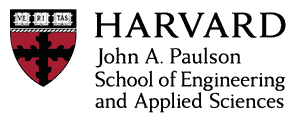

# CS1090A Introduction to Data Science

### Section 3 — Regression and One-Hot Encoding

### What does a regression coefficient actually tell you?

**Central question:** A model reports that deeper bills go with lighter penguins. Add one more column to the same model and it reports the opposite. Which answer do we give?

**Suggested pacing:** 75 minutes · roughly 40% instructor guidance / 60% student work

In [8]:
# Provided — setup. On Colab this fetches the data files this notebook needs.
# Everywhere else it does nothing except confirm they are already here.
#
# Generated at publish time; see utils/inject_colab_bootstrap.py. Editing this cell
# in the public repo is wasted work -- the next publish overwrites it.
import os
import shutil
import subprocess
import sys

_REPO    = "https://github.com/Harvard-CS1090/2026-CS1090A-public"
_REF     = "sec03-2026"
_SECTION = "sec03"

_DIRNAME = _REPO.rstrip("/").split("/")[-1].removesuffix(".git")

if os.path.isdir("data"):
    print(f"data/ is present -- nothing to fetch.")
elif "google.colab" not in sys.modules:
    raise RuntimeError(
        "This notebook reads its inputs from a data/ folder, which is not here.\n"
        "It does not fetch them from the live web -- that is deliberate, and Part 1\n"
        "explains why.\n\n"
        "Fix: get the whole folder, not just the notebook --\n"
        f"    git clone --branch {_REF} {_REPO}\n"
        f"    cd {_DIRNAME}/{_SECTION}\n"
        "    jupyter lab\n\n"
        "Then open this notebook from in there. (On Colab, this cell fetches it for you.)"
    )
else:
    print("Colab detected, no data/ -- fetching it once...")
    _tmp = "/content/_cs1090a_materials"
    if not os.path.isdir(_tmp):
        _r = subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", _REF, _REPO, _tmp],
            capture_output=True, text=True,
        )
        if _r.returncode != 0:
            raise RuntimeError(
                f"Could not download the data files from {_REPO} (ref {_REF}).\n\n"
                f"git said: {_r.stderr.strip().splitlines()[-1] if _r.stderr.strip() else 'no output'}\n\n"
                "This is not something you did wrong. Post on Ed with this message and\n"
                "a TF will sort it out; meanwhile the section notebook will not run here."
            )
    _dir = os.path.join(_tmp, _SECTION)
    _src = os.path.join(_dir, "data")
    if not os.path.isdir(_src):
        raise RuntimeError(
            f"Cloned {_REPO} at {_REF} but found no {_SECTION}/data in it.\n"
            "The published bundle is incomplete -- please report this on Ed."
        )
    shutil.copytree(_src, "data")

    # Sibling modules too, not just data/. Section 1 does `from section_helpers import
    # Recorded`; fetching data/ alone leaves that import failing three cells later,
    # which reads as "the notebook is broken" rather than "setup was incomplete".
    _mods = [f for f in os.listdir(_dir) if f.endswith(".py")]
    for _m in _mods:
        shutil.copy(os.path.join(_dir, _m), _m)

    print(f"data/ ready ({len(os.listdir('data'))} entries)"
          + (f", plus {', '.join(sorted(_mods))}." if _mods else "."))


data/ is present -- nothing to fetch.


<div style="background:#E8F1FF; border-left:6px solid #2563EB; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🎯 Objectives — what you should be able to do by the end</div>
<div>
<ul>
<li>fit a linear regression and state what its slope means in the units of the thing you are predicting;</li>
<li>fit \(k\)-nearest-neighbours regression, choose \(k\) with a validation set, and say where it and a straight line disagree;</li>
<li>one-hot encode a categorical column, and explain how many columns you get and why one level is left out; and</li>
<li>show that leaving a categorical predictor out can reverse the sign of a coefficient you were about to interpret.</li>
</ul>
</div>
</div>

## How to read this notebook

Coloured boxes tell you what to do with your hands. The colour and the one-word
name always mean the same thing.

<table style="border-collapse:separate; border-spacing:0 4px;">
<tr><td style="background:#E8F1FF; border-left:6px solid #2563EB; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>🎯 Objectives</strong></td><td style="padding:8px 12px;">What you should be able to do by the end.</td></tr>
<tr><td style="background:#FFF7CC; border-left:6px solid #D97706; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>🤔 Predict</strong></td><td style="padding:8px 12px;">Commit to a prediction <em>before</em> running the code.</td></tr>
<tr><td style="background:#E9F8EE; border-left:6px solid #16A34A; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>🏋️ Exercise</strong></td><td style="padding:8px 12px;">Write code, calculate, or modify something. Look for <code># your code here</code>.</td></tr>
<tr><td style="background:#FDECEC; border-left:6px solid #DC2626; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>💬 Discuss</strong></td><td style="padding:8px 12px;">Stop running cells. Interpret what you just saw, with a partner.</td></tr>
<tr><td style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>⭐ Insight</strong></td><td style="padding:8px 12px;">The conceptual nugget the exercise was built to deliver.</td></tr>
<tr><td style="background:#E6F7FF; border-left:6px solid #0891B2; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>💡 Reflect</strong></td><td style="padding:8px 12px;">Connect it back to your own modelling.</td></tr>
<tr><td style="background:#F3F4F6; border-left:6px solid #4B5563; padding:8px 12px; white-space:nowrap; color:#1F2937;"><strong>🧠 Takeaways</strong></td><td style="padding:8px 12px;">The handful of things to carry out of the room.</td></tr>
</table>

## Why should we care?

Linear regression is the first model most people meet, and the main reason to use it is
that its coefficients can be read. A fitted line gives you one number per predictor, and
that number looks like an answer to a question you care about: how much heavier is a
penguin, per extra millimetre of bill?

Today we take that reading seriously enough to check it. We will fit a model, read a
coefficient off it, and then add one more column to the same model and watch the
coefficient change sign. Both models run without an error and both report a plausible
number, but only one of them answers the question we thought we were asking.

**The setting.** A field team at Palmer Station, Antarctica measured 344 penguins from
three species. For each penguin the file records the length and depth of the bill, the
length of the flipper, the body mass, the island it was found on, and its sex. Body mass
is what we will predict, and the other three measurements plus the categorical columns are
what we have to predict it from.

The plan for the next 75 minutes: fit a line through one predictor and interpret it, fit
\(k\)-nearest-neighbours on that same predictor and compare, and then add the species
column to a one-predictor model and watch what it does to the coefficient we had just
read off it. That last step is a model with more than one predictor column, which
Lecture 5 covers on Monday 21 September, after this section. Part 4 says what you need
before it uses it.

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — commit to a prediction</div>
<div>
Without touching the keyboard, discuss with a partner and write your answers down.
<ol>
<li>Bill depth is how tall a penguin's bill is, top to bottom. Across all 342 penguins, is a deeper bill associated with a <em>heavier</em> or a <em>lighter</em> penguin?</li>
<li>Suppose we fit that same relationship separately within each of the three species. Would you expect the three answers to agree with the answer from question 1?</li>
</ol>
We measure both today, in Part 4.
</div>
</div>

## Part 1. The penguins and the measurements we have

The data comes from Kristen Gorman's field study at Palmer Station, on the Palmer
Archipelago off the Antarctic Peninsula, and it is distributed as the `palmerpenguins`
dataset. Each row is one penguin, measured once.

Two things about the file before we model anything. It has **344 rows**, and **two of
them have no measurements at all**: species and island are filled in, and every numeric
column is empty. A row with no predictors and no target cannot be used to fit a model or
to score one, so we drop those two. That leaves 342.

Nine of the remaining rows have a body mass and a full set of measurements but **no
recorded sex**. We keep those nine, because nothing in Parts 1 to 4 uses `sex` as a
predictor. Appendix A1 does use it, and it drops those nine rows there and says so.

Lecture 2's rule for missing values applies throughout: do not fill a missing value in
by default, and before dropping rows ask whether the rows with a missing value differ
from the rows without. For the two empty rows there is nothing to compare. For the nine
without a recorded sex, A1 drops them and states the condition under which that is safe.
Nothing in this notebook
replaces a missing value with a guess.

In [9]:
# Provided — nothing to complete here.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

sns.set_theme(style="whitegrid", context="notebook")

data_candidates = [Path("data/penguins.csv"), Path("penguins.csv")]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place penguins.csv beside this notebook or in a data/ folder.")

raw = pd.read_csv(data_path)

# The four measured numbers. A row missing all four cannot be trained on or scored.
measurements = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
df = raw.dropna(subset=measurements).reset_index(drop=True)

print(f"{len(raw)} rows in the file")
print(f"{len(df)} rows with a complete set of measurements")
print(f"{int(df['sex'].isna().sum())} of those have no recorded sex (kept; see the text above)")
display(df.head(3))

344 rows in the file
342 rows with a complete set of measurements
9 of those have no recorded sex (kept; see the text above)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


### What is in each column, and what kind of variable each one is

In Lecture 2's vocabulary, each row is one observation — one penguin, measured once —
and each column is one variable. Lecture 2 also said to ask one question of every
variable before doing anything with it: is it quantitative, ordinal, or nominal? That
answer tells you which columns today's models can use as they are. Linear regression multiplies each predictor
by a coefficient, so it can take a quantitative column as it is, and it cannot take a
nominal column until Part 4 turns it into numbers.

| Column | What it records | Type, in Lecture 2's terms |
|---|---|---|
| `species` | Adelie, Chinstrap or Gentoo | nominal: three groups, no order between them |
| `island` | Biscoe, Dream or Torgersen, where the penguin was found | nominal |
| `bill_length_mm` | how far the bill sticks out, front to back | quantitative, continuous |
| `bill_depth_mm` | how tall the bill is, top to bottom, at its base | quantitative, continuous |
| `flipper_length_mm` | flipper length | quantitative, continuous |
| `body_mass_g` | **the target.** What every model below predicts. | quantitative, continuous |
| `sex` | Male or Female, missing for nine penguins | nominal |

None of the four messiness patterns from Lecture 2 appears in this file: no values are
used as column headers, no variable is spread across both rows and columns, no cell holds
several values, and every row is the same kind of record. That is why the file goes
straight from `read_csv` into a model with no reshaping. Lecture 2's survey needed its
`languages` column split and exploded before it could be counted; nothing here needs
that.

Before choosing a predictor, look at how each measurement moves with body mass.

correlation with body_mass_g
bill_length_mm       0.595
bill_depth_mm       -0.472
flipper_length_mm    0.871


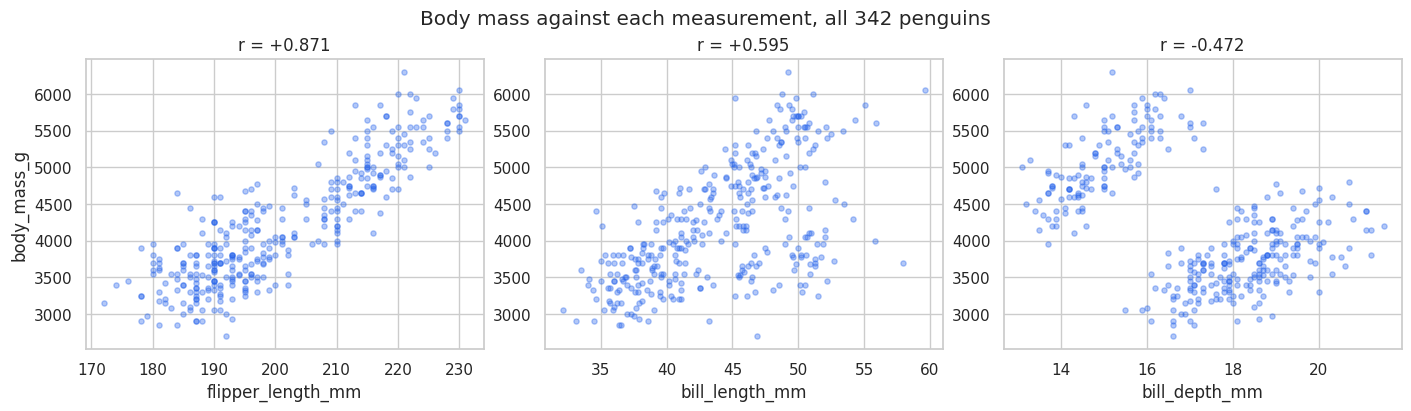

In [10]:
# Provided — how each measurement relates to body mass.
correlations = df[measurements].corr()["body_mass_g"].drop("body_mass_g")
print("correlation with body_mass_g")
print(correlations.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, feature in zip(axes, ["flipper_length_mm", "bill_length_mm", "bill_depth_mm"]):
    ax.scatter(df[feature], df["body_mass_g"], s=14, alpha=0.35, color="#2563EB")
    ax.set_xlabel(feature)
    ax.set_title(f"r = {df[feature].corr(df['body_mass_g']):+.3f}")
axes[0].set_ylabel("body_mass_g")
fig.suptitle("Body mass against each measurement, all 342 penguins")
plt.show()

Two of the three behave the way you would guess. Longer flippers go with heavier
penguins (r = +0.871), and so do longer bills (r = +0.595).

The third one does not. **Bill depth has a correlation of −0.472 with body mass**: across
these 342 penguins, a deeper bill goes with a *lighter* penguin. That is the number
Part 4 is about. Leave it alone until then, but notice that the middle panel and the
right-hand panel do not look like the same kind of picture — the right-hand one looks
like two or three separate clouds rather than one.

## Part 2. A straight line through one predictor

We start with the strongest single predictor, `flipper_length_mm`, and the simplest model
that uses it:

$$\widehat{\text{body\_mass\_g}} = \beta_0 + \beta_1 \times \text{flipper\_length\_mm}$$

Least squares picks the $\beta_0$ and $\beta_1$ that make the sum of the squared
vertical distances between the points and the line as small as it can be.

**Before we fit anything, we split the rows in two.** 80% of the penguins go into a
*training* set, which is what the model is fitted on. The other 20% go into a
*validation* set, which the model never sees during fitting and which we use to compare
models against each other. Scoring a model on the same rows it was fitted on tells you
how well it reproduced those rows, which is a different question from how well it
predicts penguins it has not seen.

One split is enough for today. Section 4 is about why one split is not enough in
general, and what to do instead.

In [20]:
#X = df[["flipper_length_mm", "sex"]]  can give a list of column names, or just one column surrounded by [[]]
# to make it 2d
X = df[["flipper_length_mm"]]
y = df['body_mass_g']

In [21]:
X

,flipper_length_mm
0,181.0
1,186.0
2,195.0
3,193.0
4,190.0
...,...
337,214.0
338,215.0
339,222.0
340,212.0


In [22]:
# Provided — one split, made once, used by every model in this notebook.
#train, val = train_test_split(df, test_size=0.20, shuffle=True, random_state=209)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=209)
print(f"{len(X_train)} penguins to train on, {len(X_val)} held back to validate on")
# only works with top line
#print("species in the training rows  :", X_train["species"].value_counts().to_dict())
#print("species in the validation rows:", X_val["species"].value_counts().to_dict())

273 penguins to train on, 69 held back to validate on


In [23]:
X_train.shape # need this to be 2dimensional (273,1)

(273, 1)

In [33]:
line = LinearRegression()
line.fit(X_train, y_train)
intercept = line.intercept_

In [34]:
slope = line.coef_

# a very simple model is just mean of values in training data (y bar)

In [29]:
y_hat_train = line.predict(X_train)
train_r2 = r2_score(y_train,y_hat_train)
train_r2

0.7568705367650458

In [31]:
# now evaluate test data too
y_hat_val = line.predict(X_val)
val_r2 = r2_score(y_val,y_hat_val)
val_r2

0.7673708264795975

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 1: fit the line and read its slope (6 min)</div>
<div>
Complete the cell below so that it fits a <code style="background:rgba(0,0,0,0.06); color:#1F2937;">LinearRegression</code> of
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">body_mass_g</code> on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">flipper_length_mm</code>, using the training rows
only, and scores it on both sets.
<p>Two notes on the code. Pass the predictor as <code style="background:rgba(0,0,0,0.06); color:#1F2937;">train[["flipper_length_mm"]]</code>
with two sets of brackets: scikit-learn requires a two-dimensional table of predictors, and
one set of brackets would give it a one-dimensional Series. The fitted slope comes back as
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">line.coef_[0]</code> — an array with one entry per predictor, even when there is
only one.</p>
</div>
</div>

In [36]:
# Fit a straight line through flipper length, then score it on both sets.

# your code here
#line = LinearRegression().fit(..., ...)     # fit on the TRAINING rows only

#slope = ...                                 # line.coef_ holds one entry per predictor
#intercept = ...                             # line.intercept_ is a single number
#line_train_r2 = r2_score(..., ...)          # scored on rows the model was fitted on
#line_val_r2 = r2_score(..., ...)            # scored on rows it has never seen

#print(f"body_mass_g = {intercept:.0f} + {slope:.1f} * flipper_length_mm")
print(f"train R2 {train_r2:.3f}   validation R2 {val_r2:.3f}")

train R2 0.767   validation R2 0.767


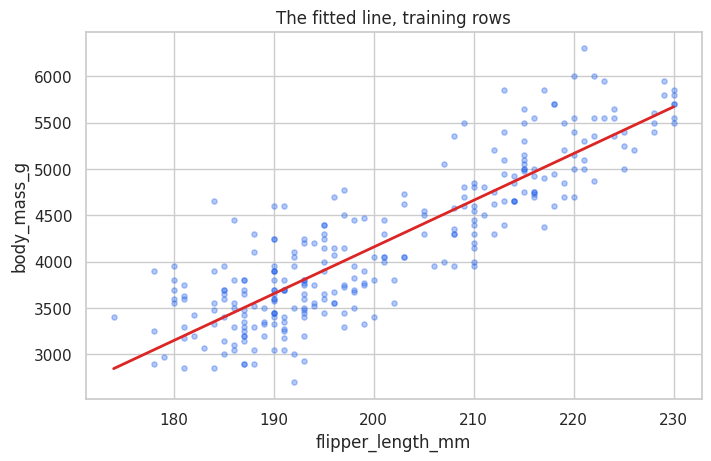

In [37]:
# Provided — the fitted line over the training rows.
# blue dots from scatter plot:
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.scatter(train["flipper_length_mm"], train["body_mass_g"], s=14, alpha=0.35, color="#2563EB")


# grid: intermediate x values that will be used to make predictions
# for all these candidate values (100 evenly spaced pts across range )
grid = pd.DataFrame({"flipper_length_mm":
                     np.linspace(train["flipper_length_mm"].min(),
                                 train["flipper_length_mm"].max(), 100)}) # making dummy x values to give to model to predict on
# give flipper length to model to make predictions on
ax.plot(grid["flipper_length_mm"], line.predict(grid), color="#DC2626", linewidth=2)
ax.set_xlabel("flipper_length_mm")
ax.set_ylabel("body_mass_g")
ax.set_title("The fitted line, training rows")
plt.show()


<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 1: what the two numbers in that line mean</div>
<div>
<ul>
<li>The slope is about <strong>+50 grams per millimetre</strong>. Say that as a sentence about penguins, out loud, to your partner. What does it predict for two penguins whose flippers differ by 10 mm?</li>
<li>The intercept is about <strong>−5,900 grams</strong>. No penguin has a negative body mass. Is the model broken?</li>
<li>Training \(R^2\) is 0.757 and validation \(R^2\) is 0.767. The model scored <em>better</em> on the rows it had never seen. Does that mean something is wrong?</li>
</ul>
</div>
</div>

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — how to read the intercept, and a negative R²</div>
<div>
<p>Two numbers this fit reports need a definition before they can be read, and both
come back in HW2.</p>
<p><strong>The intercept is a prediction at a predictor value we never observed.</strong>
It is the model's answer for a penguin with a 0 mm flipper, and the flippers here run from
172 mm to 231 mm. The model has no data anywhere near zero, so its answer there is the
result of extending a straight line, not a measurement. That does not make the intercept
useless — it sets the height of the line over the range we do have — but it does mean you
should not report it as a fact about penguins. Part 3 comes back to what both of today's
models do outside the range they were fitted on.</p>
<p><strong>\(R^2\) is measured against a specific baseline, so it can go negative.</strong>
It reports the fraction of variance the model explains relative to always predicting the
mean of the rows being scored. A model that matches that baseline scores 0, and a model
that does worse than it scores below 0. You will see a negative \(R^2\) in Part 3, and
when you do, it means the model would have been beaten by predicting one constant.</p>
</div>
</div>

## Part 3. k-nearest-neighbours on the same predictor

$k$-nearest-neighbours regression makes a prediction without fitting a line at all. To
predict the mass of a penguin with a 205 mm flipper, it finds the $k$ training penguins
whose flipper lengths are closest to 205 mm and averages their masses. That is the whole
model. Nothing is estimated when you call `.fit()`; the training rows are simply stored,
and the work happens at prediction time.

The number $k$ controls how much of the data each prediction is allowed to look at, and
the two ends of its range are worth thinking through before running anything:

- **$k = 1$** predicts each penguin's mass from the single closest training penguin.
- **$k$ equal to the number of training rows** averages every training penguin for every
  prediction, so the model returns the same number no matter what flipper length you
  give it.

In [38]:
# Provided — two facts about the training rows that the next question depends on.
distinct = train["flipper_length_mm"].nunique()
shared = train["flipper_length_mm"].map(train["flipper_length_mm"].value_counts()).gt(1).mean()
print(f"{len(train)} training penguins, {distinct} distinct flipper lengths between them")
print(f"{shared:.0%} of the training rows share their flipper length with another training row")

273 training penguins, 52 distinct flipper lengths between them
98% of the training rows share their flipper length with another training row


<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — the two ends of the range</div>
<div>
<ol>
<li>At \(k = 273\) — every training penguin averaged into every prediction — what will training \(R^2\) be? Give a number, not a description.</li>
<li>At \(k = 1\), each training penguin's nearest neighbour ought to be itself, which would make training \(R^2\) equal to 1. There are 273 training penguins and only <strong>52 distinct flipper lengths</strong> among them. Does that change your answer?</li>
</ol>
</div>
</div>

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 2: sweep k and build the train/validation table (7 min)</div>
<div>
Complete the loop below so that each value of \(k\) contributes one row holding its
training \(R^2\) and its validation \(R^2\).
<p>Use <code style="background:rgba(0,0,0,0.06); color:#1F2937;">KNeighborsRegressor(n_neighbors=k)</code>, which you fit and predict with
exactly the way you did <code style="background:rgba(0,0,0,0.06); color:#1F2937;">LinearRegression</code>. Fit on the training rows only,
the same as before.</p>
</div>
</div>

In [39]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=209)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.20, shuffle=True, random_state=209)


In [42]:
# One row per k: how well does it do on rows it stored, and on rows it did not?
k_values = [1, 3, 5, 10, 20, 30, 50, 100, len(X_train)]
# len(X_train) is the mean model
rows = []
for k in k_values:
    # your code here
    knn = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train) # setup model for data

    rows.append({
        "k": k,
        "train_r2": r2_score(y_train, knn.predict(X_train)),     # scored on the training rows, knn only needs x's to make prediction
        "val_r2": r2_score(y_val,knn.predict(X_val))       # scored on the validation rows
    })

knn_table = pd.DataFrame(rows)
display(knn_table.round(3))
print(f"the straight line from Part 2, for comparison: validation R2 {val_r2:.3f}")

,k,train_r2,val_r2
0,1,0.649,0.585
1,3,0.806,0.703
2,5,0.807,0.663
3,10,0.805,0.682
4,20,0.797,0.691
5,30,0.789,0.689
6,50,0.774,0.692
7,100,0.717,0.646
8,218,0.000,-0.036


the straight line from Part 2, for comparison: validation R2 0.767


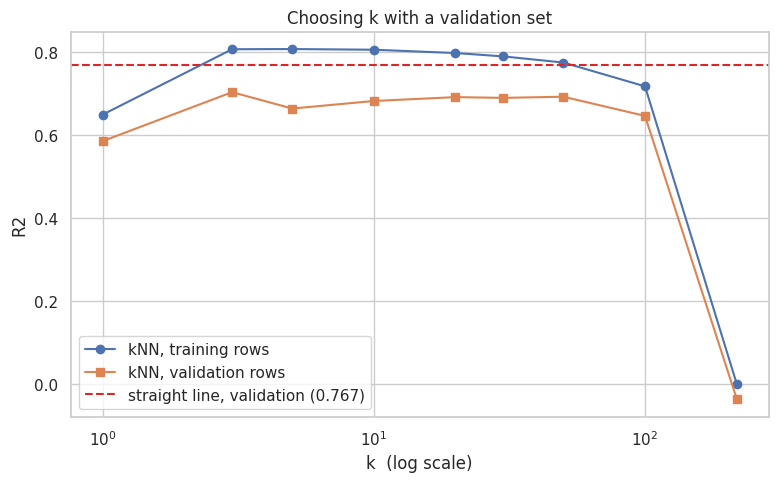

In [43]:
# Provided — the same table as a picture, with the line's score for reference.
plt.figure(figsize=(9, 5))
plt.plot(knn_table["k"], knn_table["train_r2"], marker="o", label="kNN, training rows")
plt.plot(knn_table["k"], knn_table["val_r2"], marker="s", label="kNN, validation rows")
plt.axhline(val_r2, color="#DC2626", linestyle="--",
            label=f"straight line, validation ({val_r2:.3f})")
plt.xscale("log")
plt.xlabel("k  (log scale)")
plt.ylabel("R2")
plt.title("Choosing k with a validation set")
plt.legend()
plt.show()

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 2: reading the sweep</div>
<div>
<ul>
<li>At \(k = 273\), training \(R^2\) is exactly <strong>0.000</strong> and validation \(R^2\) is very slightly negative. Where does each of those two numbers come from?</li>
<li>At \(k = 1\), training \(R^2\) is far below 1. Why, given that every training penguin is in the stored data?</li>
<li>Between about \(k = 5\) and \(k = 30\) the validation column barely moves. Which of those values would you report as the best \(k\)?</li>
</ul>
</div>
</div>

In [44]:
# Provided — re-run the same sweep under 30 different splits of the same 342 penguins.
# Nothing about the penguins changes between runs; only which rows are held back does.
sweep_ks = [k for k in k_values if k < len(X_train)]
winners, line_scores, knn_beat_line = [], [], 0

for seed in range(30):
    t, v = train_test_split(df, test_size=0.20, shuffle=True, random_state=seed)
    scores = [
        r2_score(v["body_mass_g"],
                 KNeighborsRegressor(n_neighbors=k)
                 .fit(t[["flipper_length_mm"]], t["body_mass_g"])
                 .predict(v[["flipper_length_mm"]]))
        for k in sweep_ks
    ]
    winners.append(sweep_ks[int(np.argmax(scores))])
    line_score = r2_score(v["body_mass_g"],
                          LinearRegression().fit(t[["flipper_length_mm"]], t["body_mass_g"])
                          .predict(v[["flipper_length_mm"]]))
    knn_beat_line += max(scores) > line_score
    line_scores.append(line_score)

print("how often each k won, over 30 different splits:")
print(pd.Series(winners).value_counts().sort_index().to_string())
print(f"\nthe best kNN beat the straight line on {knn_beat_line} of the 30 splits")
print(f"the straight line's own validation R2 ranged from {min(line_scores):.3f} "
      f"to {max(line_scores):.3f} across those splits")

how often each k won, over 30 different splits:
3       2
5       2
10      4
20      2
30     11
50      8
100     1

the best kNN beat the straight line on 22 of the 30 splits
the straight line's own validation R2 ranged from 0.669 to 0.844 across those splits


<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — how much the best k depends on which rows were held back</div>
<div>
<p>Over 30 different splits of the same 342 penguins, several different values of
\(k\) come out best, and none of them comes out best most of the time. The validation set is 69 rows,
and swapping which 69 is enough to change the answer. So "\(k = 30\) is best" is not a
fact about penguins; it is a fact about one particular split, and reporting it as though
it were the first thing overstates what we measured.</p>
<p>What the sweep <em>does</em> support is the shape: very small \(k\) is clearly bad,
very large \(k\) is clearly bad, and there is a broad middle where the differences are
inside the noise. Picking any value from that middle is reasonable, and picking the exact
peak is not better than picking its neighbour.</p>
<p>The same applies to the straight line: its validation \(R^2\) moves by more
than 0.1 across these 30 splits with no change to the model. Section 4 replaces the single
validation set with \(k\)-fold cross-validation, which averages over several splits
and gives you a spread to judge whether two models differ at all.</p>
</div>
</div>

### Where the line and the neighbours disagree

The two models score within a few hundredths of each other on validation, so the scores
do not separate them. They are not interchangeable, and the clearest difference shows up
outside the range of the training data.

In [45]:
# Provided — both models, evaluated at flipper lengths outside the training data.
best_k = int(knn_table.loc[knn_table["val_r2"].idxmax(), "k"])
knn_best = KNeighborsRegressor(n_neighbors=best_k).fit(X_train[["flipper_length_mm"]],
                                                       X_train["body_mass_g"])

observed_lo, observed_hi = df["flipper_length_mm"].min(), df["flipper_length_mm"].max()
print(f"measured flipper lengths run from {observed_lo:.0f} mm to {observed_hi:.0f} mm")
grid = pd.DataFrame({"flipper_length_mm":
                     np.linspace(observed_lo - 15, observed_hi + 45, 300)})

plt.figure(figsize=(9, 5))
plt.scatter(X_train["flipper_length_mm"], X_train["body_mass_g"], s=14, alpha=0.30, color="#2563EB",
            label="training penguins")
plt.plot(grid["flipper_length_mm"], line.predict(grid), color="#DC2626", linewidth=2,
         label="straight line")
plt.plot(grid["flipper_length_mm"], knn_best.predict(grid), color="#7E22CE", linewidth=2,
         label=f"kNN, k={best_k}")
plt.axvspan(observed_lo, observed_hi, color="#16A34A", alpha=0.07)
plt.text(observed_lo + 2, 6600, "flipper lengths we actually measured", color="#166534", fontsize=9)
plt.xlabel("flipper_length_mm")
plt.ylabel("body_mass_g")
plt.title("Both models, inside and outside the measured range")
plt.legend()
plt.show()

for flipper in [230, 260, 300]:
    ask = pd.DataFrame({"flipper_length_mm": [flipper]})
    print(f"flipper {flipper} mm -> line {line.predict(ask)[0]:6.0f} g, "
          f"kNN {knn_best.predict(ask)[0]:6.0f} g")

KeyError: 'body_mass_g'

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — the two models behave differently where there is no data</div>
<div>
<p>Past the largest flipper in the training set, the straight line keeps going: it
predicts 7,182 g at 260 mm and 9,199 g at 300 mm, because extending the line is the only
thing a line can do. kNN stops moving: past the last training penguin, the \(k\) nearest
neighbours are the same \(k\) penguins whatever flipper length you ask about, so every
prediction out there is the same average.</p>
<p>Neither answer is trustworthy, because neither model has any information about a 300 mm
flipper — the largest flipper measured here is 231 mm. The two models differ in how visible
that is. The line returns a specific number that depends on the assumption that the
relationship stays linear beyond the data, and nothing in the number shows that
assumption. kNN returns the average of the same 30 largest-flippered training penguins for
every input past 231 mm, and the flat line in the figure makes it visible that the
prediction has stopped responding to the input.</p>
<p>Check the range of the training predictor before you trust a prediction. Neither model
raises an error for a 300 mm flipper, so the check has to be yours.</p>
</div>
</div>

## Part 4. Adding a categorical predictor, and what it does to a coefficient

Everything so far has used numeric columns. Two columns in this dataset are not numeric:
`species` and `island`. A linear model cannot take the string `"Gentoo"` — it multiplies
predictors by coefficients, and there is no useful way to multiply a word by a number — so
a categorical column has to be turned into numbers before it can be used.

**A note on timing.** Lecture 4 covers simple linear regression and \(k\)-nearest
neighbours, which is everything Parts 2 and 3 used. Once `species` has been turned into
numbers, the model in this part has several predictor columns at once, and that is
multiple linear regression, which is Lecture 5, on Monday 21 September, after every
section this week. This part uses it anyway, because HW2 Part 2 needs it and this section
is the rehearsal for HW2. Treat it as a preview. Three facts are all you need: you pass a
list of column names to `.fit()` instead of one; `model.coef_` comes back with one entry
per column; and each coefficient describes two rows that differ in that column and match
on all the others. Nothing below depends on anything else from Lecture 5.

Before we encode anything, we fit the model that has the problem. We go back to
`bill_depth_mm`, the measurement whose correlation with body mass was negative, and fit it
on its own. The cell also computes the model's **residuals**: for each training penguin,
its actual mass minus the mass the model predicted for it, so a positive residual is a
penguin the model predicted too light. Plotting residuals against the model's predictions
is a standard check on a fitted model, and Lecture 5 and Section 4 cover how to read that
plot in general. Here we use it for one thing only.


In [ ]:
# Provided — bill depth by itself, and what its residuals look like once we split them
# by a column the model never saw.
depth_only = LinearRegression().fit(train[["bill_depth_mm"]], train["body_mass_g"])
depth_only_val_r2 = r2_score(val["body_mass_g"], depth_only.predict(val[["bill_depth_mm"]]))
depth_residuals = train["body_mass_g"] - depth_only.predict(train[["bill_depth_mm"]])

print(f"body_mass_g = {depth_only.intercept_:.0f} + {depth_only.coef_[0]:.1f} * bill_depth_mm")
print(f"train R2 {depth_only.score(train[['bill_depth_mm']], train['body_mass_g']):.3f}   "
      f"validation R2 {depth_only_val_r2:.3f}")
print("\nmean residual by species, from a model that was never given species:")
print(pd.DataFrame({"residual": depth_residuals, "species": train["species"]})
      .groupby("species")["residual"].agg(["mean", "std", "count"]).round(0).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].scatter(depth_only.predict(train[["bill_depth_mm"]]), depth_residuals,
                s=16, alpha=0.40, color="#7E22CE")
axes[0].axhline(0, color="#4B5563", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("predicted body_mass_g")
axes[0].set_ylabel("residual, g")
axes[0].set_title("Residuals of the bill-depth model")

for name, group in train.groupby("species"):
    axes[1].scatter(depth_only.predict(group[["bill_depth_mm"]]),
                    group["body_mass_g"] - depth_only.predict(group[["bill_depth_mm"]]),
                    s=16, alpha=0.55, label=name)
axes[1].axhline(0, color="#4B5563", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("predicted body_mass_g")
axes[1].set_title("The same residuals, coloured by species")
axes[1].legend()
plt.show()

The left-hand panel plots each training penguin's residual against the mass the model
predicted for it. It is a wide band with no shape to it, from a model that explains about
23% of the variance in body mass, and nothing in it says what to do next.

The right-hand panel adds a column the model was never given, and the band separates into
groups. **Gentoos are on average 466 g heavier than this model predicts, and Adelies are
280 g lighter.** A model that is wrong by a consistent amount within each group is missing
the column that identifies the group.

<div style="background:#FFF7CC; border-left:6px solid #D97706; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🤔 Predict — what happens to the slope</div>
<div>
<p>We are about to add <code style="background:rgba(0,0,0,0.06); color:#1F2937;">species</code> to that model and refit. The slope on
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">bill_depth_mm</code> is currently <strong>−201.4</strong> grams per millimetre.
Commit to an answer for each, and write it down:</p>
<ol>
<li>Will \(R^2\) go up, down, or stay about the same?</li>
<li>Will the slope on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">bill_depth_mm</code> become more negative, move closer to zero, or become positive?</li>
</ol>
</div>
</div>

### Turning a categorical column into numbers

**One-hot encoding** replaces a categorical column with one new column per category, each
holding 1 when the row has that category and 0 when it does not. `pandas` does it with
`pd.get_dummies`.

The number of columns you get is the part to be careful about, so look at both versions.

In [ ]:
# Provided — the same column encoded two ways. One penguin of each species, because the
# number of columns you get is the thing to look at.
example = df.loc[df.groupby("species").head(1).index, ["species"]]
display(example)

print("every level gets a column (drop_first=False):")
display(pd.get_dummies(example, columns=["species"], dtype=int))

print("one level is left out (drop_first=True):")
display(pd.get_dummies(example, columns=["species"], drop_first=True, dtype=int))

### Why one level is left out

Three species produce three indicator columns, and those three columns add up to 1 in
every row: each penguin is exactly one species. A linear model already carries an
intercept, which behaves like a column of 1s. So the three indicators together are an
exact copy of a column the model already has, and there are infinitely many sets of
coefficients that give exactly the same predictions — add 500 to the intercept, subtract
500 from all three species coefficients, and every prediction is unchanged.

That is why `drop_first=True` exists. With one level left out, the remaining coefficients
are pinned down, and they are read **relative to the level that was dropped**. Here Adelie
is dropped, so the Chinstrap coefficient is the predicted difference in mass between a
Chinstrap and an Adelie of the same bill depth, and likewise for Gentoo. The dropped level
is still in the model: the intercept is the prediction for an Adelie, before bill depth is
added.

In [ ]:
# Provided — two different sets of coefficients, one identical set of predictions.
all_three = pd.get_dummies(train[["bill_depth_mm", "species"]], columns=["species"], dtype=int)
redundant = LinearRegression().fit(all_three, train["body_mass_g"])

print("columns:", list(all_three.columns))
print("\nwhat the solver returned with all three species columns present:")
print(pd.Series(redundant.coef_, index=all_three.columns).round(1).to_string())
print(f"intercept {redundant.intercept_:.1f}")

# Now move 500 g out of each species coefficient and into the intercept, by hand.
species_columns = [c for c in all_three.columns if c.startswith("species_")]
by_hand = pd.Series(redundant.coef_, index=all_three.columns).copy()
by_hand[species_columns] -= 500

print("\nthe same model with 500 g moved from each species coefficient into the intercept:")
print(by_hand.round(1).to_string())
print(f"intercept {redundant.intercept_ + 500:.1f}")

original = redundant.predict(all_three)
moved = all_three.to_numpy() @ by_hand.to_numpy() + redundant.intercept_ + 500
print(f"\nlargest difference between the two sets of predictions: "
      f"{np.abs(moved - original).max():.2e} g")

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise 3: encode species, refit, and read the slope (10 min)</div>
<div>
<p>This is the exercise the section is built around. Complete the cell so that it one-hot
encodes <code style="background:rgba(0,0,0,0.06); color:#1F2937;">species</code> with <code style="background:rgba(0,0,0,0.06); color:#1F2937;">drop_first=True</code>, fits a
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">LinearRegression</code> on bill depth plus the encoded columns, and scores it on
the validation rows.</p>
<p>One thing to watch: encode the training rows and the validation rows separately and
you can get different columns from each, if a category happens not to appear in one of
them. The provided <code style="background:rgba(0,0,0,0.06); color:#1F2937;">reindex</code> line forces the validation matrix to have the
training matrix's columns, filling any missing one with 0. On this split all three species
appear in both halves so the line changes nothing; on a smaller validation set it would be
the difference between working code and an error.</p>
</div>
</div>

In [ ]:
# Encode species, refit bill depth alongside it, and compare with the model above.

# your code here
train_encoded = pd.get_dummies(...)     # columns=["species"], drop_first=True, dtype=int
val_encoded = pd.get_dummies(...)       # the same treatment, on the validation rows

# Provided — give the validation matrix exactly the training matrix's columns.
val_encoded = val_encoded.reindex(columns=train_encoded.columns, fill_value=0)

# your code here
with_species = LinearRegression().fit(..., ...)
with_species_val_r2 = r2_score(..., ...)

print("columns the model now sees:", list(train_encoded.columns))
print()
print(f"bill depth alone       : {depth_only.coef_[0]:+8.1f} g per mm    "
      f"validation R2 {depth_only_val_r2:.3f}")
print(f"bill depth with species: {with_species.coef_[0]:+8.1f} g per mm    "
      f"validation R2 {with_species_val_r2:.3f}")
print()
print(pd.Series(dict(zip(train_encoded.columns, with_species.coef_.round(1)))).to_string())
print(f"intercept {with_species.intercept_:.1f}")

In [ ]:
# Provided — the picture behind both numbers.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
colours = {"Adelie": "#2563EB", "Chinstrap": "#D97706", "Gentoo": "#16A34A"}
depth_grid = np.linspace(train["bill_depth_mm"].min(), train["bill_depth_mm"].max(), 100)
depth_frame = pd.DataFrame({"bill_depth_mm": depth_grid})

for name, group in train.groupby("species"):
    for ax in axes:
        ax.scatter(group["bill_depth_mm"], group["body_mass_g"], s=18, alpha=0.55,
                   color=colours[name], label=name)

axes[0].plot(depth_grid, depth_only.predict(depth_frame), color="#DC2626", linewidth=2.5)
axes[0].set_title(f"One line for all penguins: {depth_only.coef_[0]:+.1f} g/mm")

for name in colours:
    design = pd.DataFrame({
        "bill_depth_mm": depth_grid,
        "species_Chinstrap": int(name == "Chinstrap"),
        "species_Gentoo": int(name == "Gentoo"),
    })
    axes[1].plot(depth_grid, with_species.predict(design), color=colours[name], linewidth=2.5)
axes[1].set_title(f"One line per species, same slope: {with_species.coef_[0]:+.1f} g/mm")

for ax in axes:
    ax.set_xlabel("bill_depth_mm")
    ax.set_ylabel("body_mass_g")
axes[0].legend(title="species")
plt.show()

print("species averages over all 342 penguins, which is where the reversal comes from:")
print(df.groupby("species")[["bill_depth_mm", "body_mass_g"]].mean().round(1).to_string())

<div style="background:#FDECEC; border-left:6px solid #DC2626; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💬 Discuss — Checkpoint 3: reading the refitted model</div>
<div>
<ul>
<li>The coefficient on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">bill_depth_mm</code> went from <strong>−201.4</strong> to <strong>+260.6</strong> g per mm, and validation \(R^2\) went from <strong>0.183</strong> to <strong>0.804</strong>. Using the right-hand figure, say in one sentence where the reversal comes from.</li>
<li>The coefficient on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">species_Gentoo</code> is about <strong>+2,268</strong>. Say what that number means, including which species it is measured against.</li>
<li>The coefficient on <code style="background:rgba(0,0,0,0.06); color:#1F2937;">species_Chinstrap</code> is about <strong>+6.7</strong> — near zero. What does a near-zero coefficient on a one-hot column tell you?</li>
</ul>
</div>
</div>

<div style="background:#F3E8FF; border-left:6px solid #7E22CE; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">⭐ Insight — a categorical you left out can reverse a coefficient, with nothing on screen to warn you</div>
<div>
<p>Both models ran without printing a warning. The first reported that a millimetre of
extra bill depth goes with 201 grams <em>less</em> body mass, and the second, on the same
342 penguins, reported 261 grams <em>more</em>. If you had fitted only the first and
written down what its coefficient said, the direction of the effect would have been wrong,
and nothing in the output would have told you.</p>
<p>A relationship that runs one way within every group and the opposite way across the
pooled data has a name: it is called <strong>Simpson's paradox</strong>. The right-hand
figure above is a picture of it. Each species has its own upward line — deeper-billed
penguins of the same species are heavier — and a single line through all three species at
once slopes down, because Gentoos are both the shallowest-billed group and much the
heaviest. The one-hot columns are what let the model fit the first thing instead of the
second.</p>
<p>This situation is common. Groups in real data differ in more than one way at once — three species that differ in both bill depth and
body mass, two hospitals that differ in both treatment and patient severity, two cohorts
that differ in both intervention and starting score. Whenever the groups differ in the
predictor <em>and</em> in the target, pooling them gives you a number that describes
neither group.</p>
<p>Two habits follow from it.
<strong>Plot the residuals of a model against a categorical column you did not include</strong>,
which is what the right-hand panel at the start of this part did: a consistent offset within a group is
the signal that the group matters. And <strong>before you interpret any coefficient, write
down the list of columns that were in the model with it</strong>, because that list is part
of what the coefficient means.</p>
<p>This is also why HW2 asks you to measure the \(R^2\) gain from adding a neighbourhood
column rather than assuming it. The gain here was 0.183 to 0.804 on validation, and the
sign change came with it.</p>
</div>
</div>

### Categories with an order, and categories without one

`species` has no order. Adelie, Chinstrap and Gentoo are three different things, and no
arrangement of them is more correct than another. A category like that is called
**nominal**, and one-hot encoding is the right treatment: each level gets its own column
and its own coefficient, and the model is never told that one level sits between two
others.

Some categorical columns do have an order. Lecture 2's example was shirt size: L is
larger than M, and the step from S to M is not known to be the same size as the step from
L to XL. Those are **ordinal**. Lecture 2 used that example to say you may take the median
of an ordinal variable but not its mean, because a mean assumes the steps between levels
are equal. The same rule applies to encoding. Mapping the levels to 1, 2, 3, 4 and
treating the column as numeric gives the model one coefficient for the column, and that
coefficient is a per-step effect: it says the change from S to M is the same number of
grams as the change from L to XL. That is the same assumption a mean makes, and it is
sometimes reasonable and often not. One-hot encoding gives each level its own coefficient
and assumes nothing about the spacing, so you can one-hot encode an ordinal column too,
and often should.

There is no ordinal column in this dataset, so this is the whole treatment of it here.
What matters for HW2 is the distinction and the reason: **an ordered category encoded as
a number carries an assumption about the spacing between its levels, and one-hot encoding
does not make that assumption.**

<div style="background:#E6F7FF; border-left:6px solid #0891B2; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">💡 Reflect — one quiet minute</div>
<div>
Go back to the two predictions you wrote down at the start.
<ol>
<li>You predicted whether a deeper bill goes with a heavier or a lighter penguin. Which answer did the pooled model give, and which answer did the model with species give?</li>
<li>Think of a dataset you have worked with, in this course or anywhere else. Name one categorical column in it whose groups probably differ in both a predictor and the target. That is the column to check before you report any coefficient from it.</li>
</ol>
</div>
</div>

<div style="background:#F3F4F6; border-left:6px solid #4B5563; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🧠 Takeaways — three things to carry out of the room</div>
<div>
<ol>
<li><strong>State what a regression coefficient means in the units of the target, and name the other columns in the model when you do.</strong> The slope on flipper length was +50.4 g per mm: two penguins whose flippers differ by one millimetre are predicted to differ by about 50 g. Once a model has more than one column, its coefficient on any one of them describes two penguins that match on the others, which is a different question, so the list of columns is part of what the number means.</li>
<li><strong>Plot residuals against a column the model does not contain, and treat a consistent offset within a group as a missing predictor.</strong> The bill-depth model predicted Gentoos about 466 g too light and Adelies about 280 g too heavy, which is what told us to add <code>species</code>. The residual plot on its own, without the colouring, looked like nothing in particular.</li>
<li><strong>One-hot encode a categorical predictor before deciding it does not matter, because leaving it out can reverse a coefficient rather than just weaken it.</strong> Adding species moved bill depth's coefficient from −201.4 to +260.6 g per mm and validation \(R^2\) from 0.183 to 0.804. Both models ran without an error and neither printed a warning.</li>
</ol>
</div>
</div>

---

## Appendix — three things to try later

**You are not expected to reach these during section, and nothing below is assessed.** The
section ends at the takeaways above. These are here for afterwards.

- **A1** adds `sex` as a second categorical column, which means dealing with the nine
  penguins whose sex was never recorded.
- **A2** adds `island`, and measures how little it changes the model.
- **A3** lets each species have its own slope instead of sharing one.

<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise — A1. What is sex worth as a predictor?</div>
<div>
<p>Nine penguins have a full set of measurements and no recorded sex. Drop those nine,
re-split the remaining 333, and compare a bill-depth-plus-species model against a
bill-depth-plus-species-plus-sex model on the same rows.</p>
<p>Note why the comparison has to be on the same rows: dropping nine penguins changes the
validation set, and a score computed on a different set of rows is not comparable with
one computed on this section's split. Both models below are fitted and scored on the
333-row split, so the only difference between them is the added column.</p>
</div>
</div>

In [ ]:
# your code here


<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise — A2. What does island add?</div>
<div>
<p>Add <code style="background:rgba(0,0,0,0.06); color:#1F2937;">island</code> to the bill-depth-plus-species model from Part 4 and score
it on the same validation rows. Then cross-tabulate <code style="background:rgba(0,0,0,0.06); color:#1F2937;">species</code> against
<code style="background:rgba(0,0,0,0.06); color:#1F2937;">island</code> and explain the result you got.</p>
</div>
</div>

In [ ]:
# your code here


<div style="background:#E9F8EE; border-left:6px solid #16A34A; padding:14px 18px; margin:16px 0; border-radius:6px; color:#1F2937;">
<div style="font-size:1.15em; font-weight:700; margin-bottom:6px;">🏋️ Exercise — A3. One slope per species, instead of one shared slope</div>
<div>
<p>The Part 4 model gives each species its own intercept and makes them all share a single
slope on bill depth — which is why the three lines in the right-hand figure are parallel.
To let each species have its own slope as well, add <strong>interaction</strong> columns:
multiply each species indicator by <code style="background:rgba(0,0,0,0.06); color:#1F2937;">bill_depth_mm</code>.</p>
<p>Fit that model, score it on the validation rows, and also fit the three species
separately to see the slopes it is trying to match.</p>
</div>
</div>

In [ ]:
# your code here
